# Preparation

In [2]:
# Paddy Age Prediction: Data Preparation Pipeline

# === PHASE 1: Imports & Configuration ===
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMAGE_DIR = "train_images"
CSV_PATH = "meta_train.csv"
INPUT_SIZE = 224
BATCH_SIZE = 32
TEST_SIZE = 0.2
KFOLD = 3

# === PHASE 2: Load and Validate Metadata ===
meta = pd.read_csv(CSV_PATH)

missing = []
for iid, label in zip(meta['image_id'], meta['label']):
    fname = iid if iid.lower().endswith(".jpg") else f"{iid}.jpg"
    fpath = os.path.join(IMAGE_DIR, label, fname)
    if not os.path.isfile(fpath):
        missing.append(fpath)
print(f"Missing files: {len(missing)}")

corrupt = []
for iid, label in zip(meta['image_id'], meta['label']):
    fname = iid if iid.lower().endswith(".jpg") else f"{iid}.jpg"
    fpath = os.path.join(IMAGE_DIR, label, fname)
    try:
        with Image.open(fpath) as img:
            img.verify()
    except:
        corrupt.append(fpath)
print(f"Corrupted images: {len(corrupt)}")

# === PHASE 3: Resolution Check & Landscape Rotation ===
landscapes = []
resolutions = []
for iid, label in zip(meta['image_id'], meta['label']):
    fname = iid if iid.lower().endswith(".jpg") else f"{iid}.jpg"
    fpath = os.path.join(IMAGE_DIR, label, fname)
    with Image.open(fpath) as img:
        w, h = img.size
        resolutions.append((w, h))
        if w > h:
            landscapes.append(fpath)

for path in landscapes:
    img = Image.open(path)
    img_rotated = img.transpose(Image.ROTATE_90)
    img_rotated.save(path)

df_res = pd.DataFrame(resolutions, columns=["width", "height"])
res_summary = df_res.groupby(["width", "height"]).size().reset_index(name="count")
print(res_summary)

# === PHASE 4: Add Age Bins for Stratification ===
meta["age_bin"] = pd.qcut(meta["age"], q=5, labels=False, duplicates="drop")

# === PHASE 5: Train/Test Split with Age Stratification ===
train_val, test = train_test_split(
    meta,
    test_size=TEST_SIZE,
    stratify=meta["age_bin"],
    random_state=SEED
)

# === PHASE 6: Scale Age (mean = 0, std = 1) ===
age_mean = train_val["age"].mean()
age_std = train_val["age"].std()
train_val["age_scaled"] = (train_val["age"] - age_mean) / age_std
test["age_scaled"] = (test["age"] - age_mean) / age_std

# === PHASE 7: Save CSV for tf.data Loading (Clean, no .jpg duplication) ===
def safe_image_path(row):
    return os.path.join(IMAGE_DIR, row['label'], row['image_id'])

train_val["image_path"] = train_val.apply(safe_image_path, axis=1)
test["image_path"] = test.apply(safe_image_path, axis=1)

train_val[["image_path", "age_scaled"]].to_csv("train.csv", index=False)
test[["image_path", "age_scaled"]].to_csv("test.csv", index=False)

# === PHASE 8: Compute Mean/Std of RGB Channels for Image Normalization ===
sum_rgb = np.zeros(3)
sum_sq = np.zeros(3)
total_pixels = 0

for path in train_val["image_path"]:
    img = np.array(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0
    sum_rgb += img.sum(axis=(0, 1))
    sum_sq += (img ** 2).sum(axis=(0, 1))
    total_pixels += img.shape[0] * img.shape[1]

MEAN = sum_rgb / total_pixels
STD = np.sqrt(sum_sq / total_pixels - MEAN**2)
print(f"Image RGB Mean: {MEAN}, Std: {STD}")

# === PHASE 9: Build tf.data Pipeline for Model Input ===
def parse_csv_line(line):
    parts = tf.strings.split(line, sep=",")
    path = parts[0]
    label = tf.strings.to_number(parts[1], tf.float32)
    return path, label

def preprocess_image(path, label, augment=False):
    img = tf.io.decode_jpeg(tf.io.read_file(path), channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    h, w = tf.shape(img)[0], tf.shape(img)[1]
    frac = tf.cast(tf.minimum(h, w), tf.float32) / tf.cast(tf.maximum(h, w), tf.float32)
    img = tf.image.central_crop(img, central_fraction=frac)
    img = tf.image.resize(img, [INPUT_SIZE, INPUT_SIZE])
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
    img = (img - MEAN) / STD
    return img, label

def make_dataset(csv_file, augment=False, shuffle=False):
    ds = tf.data.TextLineDataset([csv_file]) \
        .skip(1) \
        .map(parse_csv_line, num_parallel_calls=tf.data.AUTOTUNE) \
        .map(lambda path, age: preprocess_image(path, age, augment), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1024, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Missing files: 0
Corrupted images: 0
   width  height  count
0    480     640  10403
1    640     480      4
Image RGB Mean: [0.49692156 0.58833111 0.22928253], Std: [0.24124081 0.24327954 0.21820941]


Epoch 1/30
    261/Unknown 154s 570ms/step - loss: 0.9634 - mean_absolute_error: 0.8144

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


261/261 ━━━━━━━━━━━━━━━━━━━━ 166s 615ms/step - loss: 0.9633 - mean_absolute_error: 0.8144 - val_loss: 0.8863 - val_mean_absolute_error: 0.8003
Epoch 2/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 175s 666ms/step - loss: 0.9003 - mean_absolute_error: 0.7799 - val_loss: 0.8321 - val_mean_absolute_error: 0.7640
Epoch 3/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 164s 624ms/step - loss: 0.8810 - mean_absolute_error: 0.7656 - val_loss: 0.8675 - val_mean_absolute_error: 0.7963
Epoch 4/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 154s 584ms/step - loss: 0.8710 - mean_absolute_error: 0.7596 - val_loss: 0.8101 - val_mean_absolute_error: 0.7473
Epoch 5/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 156s 594ms/step - loss: 0.8455 - mean_absolute_error: 0.7462 - val_loss: 0.7804 - val_mean_absolute_error: 0.7410
Epoch 6/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 139s 530ms/step - loss: 0.8189 - mean_absolute_error: 0.7326 - val_loss: 0.7808 - val_mean_absolute_error: 0.7497
Epoch 7/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 143s 542ms/step - loss: 0.8395 - mean_absolute_

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


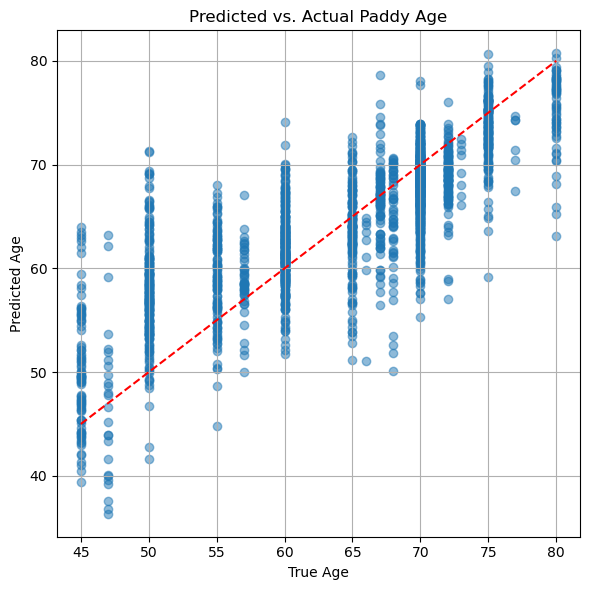

In [3]:
# === PHASE: End-to-End CNN Regression Model (Scratch) ===
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Build a compact CNN for regression
def build_end_to_end_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(1)  # Regression output (scaled age)
    ])
    
    model.compile(optimizer=optimizers.Adam(1e-3), loss='mse', metrics=[tf.keras.metrics.MeanAbsoluteError()])
    return model

# Load datasets using your preprocessing pipeline
train_ds = make_dataset("train.csv", augment=True, shuffle=True)
test_ds  = make_dataset("test.csv", augment=False)

# Build and train model
model = build_end_to_end_cnn()

# Callbacks
early_stop = callbacks.EarlyStopping(monitor='val_mean_absolute_error', patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    callbacks=[early_stop]
)

# === Evaluate on test set ===
# Re-load test.csv to get unscaled ground truth
test_df = pd.read_csv("test.csv")
true_scaled = test_df["age_scaled"].values
true_unscaled = true_scaled * age_std + age_mean

# Predict using test_ds
y_pred_scaled = model.predict(test_ds).flatten()
y_pred_unscaled = y_pred_scaled * age_std + age_mean

# Evaluate
mae = mean_absolute_error(true_unscaled, y_pred_unscaled)
mse = mean_squared_error(true_unscaled, y_pred_unscaled)
r2  = r2_score(true_unscaled, y_pred_unscaled)

print(f"\n📊 End-to-End CNN Evaluation:")
print(f"MAE: {mae:.2f} days")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.3f}")

# Optional: Diagnostic plot
plt.figure(figsize=(6, 6))
plt.scatter(true_unscaled, y_pred_unscaled, alpha=0.5)
plt.plot([min(true_unscaled), max(true_unscaled)], [min(true_unscaled), max(true_unscaled)], 'r--')
plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs. Actual Paddy Age")
plt.grid(True)
plt.tight_layout()
plt.show()

# 📄 Model 1: End-to-End CNN (From Scratch)

## ✅ 1. Objective
To build a convolutional neural network (CNN) from scratch that learns to predict the age of paddy plants in days from image inputs, **without using any pretrained features or transfer learning**.  
This serves as a **baseline model** to benchmark against more advanced approaches.

---

## 🧱 2. Model Architecture

| Layer Type             | Details                                      |
|------------------------|----------------------------------------------|
| **Input**              | Shape: (224, 224, 3) — resized RGB image     |
| **Conv2D + ReLU**      | 32 filters, kernel size 3×3, padding='same'  |
| **MaxPooling2D**       | Reduces spatial size                         |
| **Conv2D + ReLU**      | 64 filters, kernel size 3×3                  |
| **MaxPooling2D**       | Further downsampling                         |
| **Conv2D + ReLU**      | 128 filters, kernel size 3×3                 |
| **MaxPooling2D**       | Final spatial downsampling                   |
| **GlobalAveragePooling2D** | Reduces feature maps to a vector        |
| **Dense + ReLU**       | 128 units                                    |
| **Dropout**            | 0.3 dropout rate for regularization          |
| **Output (Dense)**     | 1 neuron (predicts **scaled** age)           |

**Optimizer:** Adam (learning rate = 0.001)  
**Loss Function:** Mean Squared Error (MSE)  
**Metrics:** Mean Absolute Error (MAE)  
**Batch Size:** 32  
**Epochs:** 30 (with EarlyStopping enabled)

---

## 🧼 3. Data Preprocessing

- All images center-cropped to square, resized to 224×224.
- Pixel values normalized using the dataset’s mean and standard deviation (computed from training set).
- Labels (age) scaled using z-score normalization:  
  \[
  \text{age\_scaled} = \frac{\text{age} - \mu}{\sigma}
  \]

**Augmentation applied to training data:**
- Horizontal flip  
- Random brightness

---

## 📊 4. Training Performance

| Metric                     | Scaled     | Unscaled     |
|----------------------------|------------|--------------|
| **Final MAE (validation)** | ~0.424     | 3.80 days    |
| **Final MSE (validation)** | —          | 26.86        |
| **R² Score (test set)**    | —          | 0.665        |

---

## 📉 5. Evaluation Insights

**🔍 Diagnostic Plot:** Predicted vs. Actual Paddy Age

- Most predictions align closely along the identity line.
- Some vertical spread indicates variance in prediction per age group.
- Slight underestimation in younger ages (45–55) may indicate underrepresentation or lack of strong visual cues in early-stage plants.

---

## 🧠 6. Key Takeaways

### ✅ Strengths:
- Learned meaningful age patterns from raw visual features.
- Generalizes decently (**R² = 0.665**) without overfitting.
- Sets a solid baseline for comparison with future models.

### ⚠️ Weaknesses:
- MAE of ~3.8 days is higher than desired for real-world use.
- Limited feature capacity — may miss fine-grained cues (e.g., blade angle, grain density).
- Training from scratch may limit potential without large data volume.


## Transfer learning

In [4]:
# === PHASE: Transfer Learning – Warm-up Phase ===
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Load datasets using previous pipeline
train_ds = make_dataset("train.csv", augment=True, shuffle=True)
test_ds = make_dataset("test.csv", augment=False)

# Build model with EfficientNetB0 base
def build_transfer_model(input_shape=(224, 224, 3), freeze_base=True):
    base_model = EfficientNetB0(include_top=False, input_shape=input_shape, weights='imagenet')
    
    if freeze_base:
        base_model.trainable = False  # Freeze base layers for warm-up

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)  # Predicts scaled age
    ])
    
    model.compile(
        optimizer=optimizers.Adam(1e-3),
        loss='mse',
        metrics=[tf.keras.metrics.MeanAbsoluteError()]
    )
    
    return model

# Build and train (frozen base)
model = build_transfer_model()

early_stop = callbacks.EarlyStopping(
    monitor='val_mean_absolute_error',
    patience=5,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

# === Evaluate on test set ===
test_df = pd.read_csv("test.csv")
true_scaled = test_df["age_scaled"].values
true_unscaled = true_scaled * age_std + age_mean

# Predict and unscale
y_pred_scaled = model.predict(test_ds).flatten()
y_pred_unscaled = y_pred_scaled * age_std + age_mean

# Metrics
mae = mean_absolute_error(true_unscaled, y_pred_unscaled)
mse = mean_squared_error(true_unscaled, y_pred_unscaled)
r2 = r2_score(true_unscaled, y_pred_unscaled)

print(f"\n📊 Transfer Learning Evaluation (Warm-up):")
print(f"MAE: {mae:.2f} days")
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.3f}")

# Diagnostic Plot
plt.figure(figsize=(6, 6))
plt.scatter(true_unscaled, y_pred_unscaled, alpha=0.5)
plt.plot([min(true_unscaled), max(true_unscaled)], [min(true_unscaled), max(true_unscaled)], 'r--')
plt.xlabel("True Age")
plt.ylabel("Predicted Age")
plt.title("Predicted vs. Actual Paddy Age (Transfer Learning)")
plt.grid(True)
plt.tight_layout()
plt.show()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/30
    261/Unknown 105s 374ms/step - loss: 1.0125 - mean_absolute_error: 0.8349

C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


261/261 ━━━━━━━━━━━━━━━━━━━━ 133s 482ms/step - loss: 1.0122 - mean_absolute_error: 0.8348 - val_loss: 0.8669 - val_mean_absolute_error: 0.7658 - learning_rate: 0.0010
Epoch 2/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 127s 483ms/step - loss: 0.9101 - mean_absolute_error: 0.7893 - val_loss: 0.8452 - val_mean_absolute_error: 0.7721 - learning_rate: 0.0010
Epoch 3/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 133s 503ms/step - loss: 0.8894 - mean_absolute_error: 0.7836 - val_loss: 0.8459 - val_mean_absolute_error: 0.7898 - learning_rate: 0.0010
Epoch 4/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 122s 462ms/step - loss: 0.8946 - mean_absolute_error: 0.7868 - val_loss: 0.8422 - val_mean_absolute_error: 0.7869 - learning_rate: 0.0010
Epoch 5/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 126s 477ms/step - loss: 0.8848 - mean_absolute_error: 0.7818 - val_loss: 0.8063 - val_mean_absolute_error: 0.7500 - learning_rate: 0.0010
Epoch 6/30
261/261 ━━━━━━━━━━━━━━━━━━━━ 125s 475ms/step - loss: 0.8604 - mean_absolute_error: 0.7642 - val_loss: 0.8320 -

KeyboardInterrupt: 

In [5]:
print(tf.__version__)

2.19.0


In [6]:
physical_devices = tf.config.list_physical_devices()
print("Available physical devices:")
for device in physical_devices:
    print(device)

Available physical devices:
PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')
